<a href="https://colab.research.google.com/github/ROBERTODHIAMBO2024/Crowdfunding_ETL/blob/main/DualLens_Analytics_AssignmentWK4_JHU_Agentic_AI_Project_1_RobertOdhiambo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

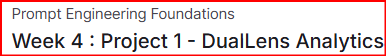

# **Description**

**Project 1 - DualLens Analytics**
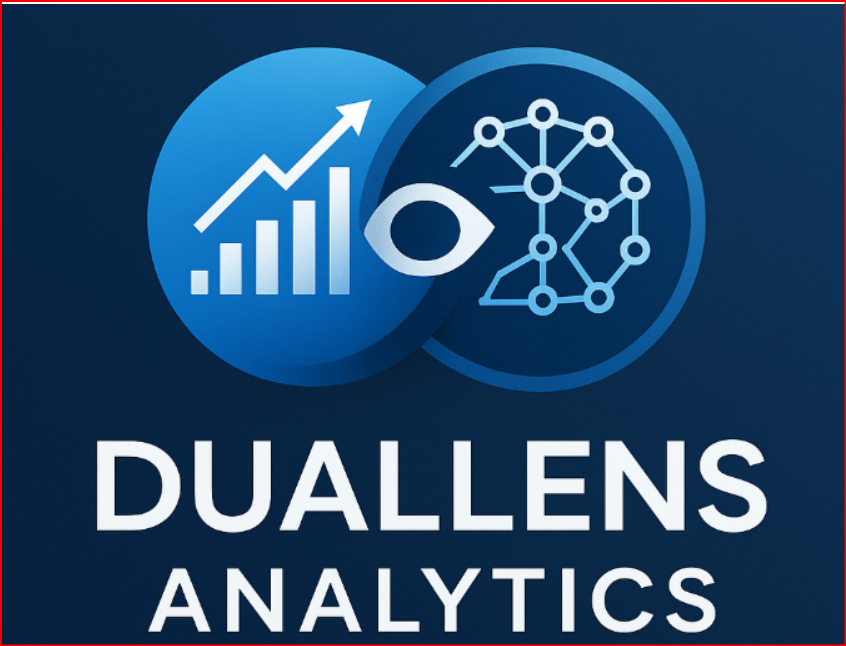

# **Background Story**

In the rapidly evolving world of finance and technology, investors are constantly seeking ways to make smarter decisions by combining traditional financial analysis with emerging technological insights. While stock market trends provide a numerical perspective on growth, an organization’s initiatives in cutting-edge fields like Artificial Intelligence (AI) reveal its future readiness and innovation potential. However, analyzing both dimensions - quantitative financial performance and qualitative AI initiatives - requires sifting through multiple, diverse data sources: stock data from platforms like Yahoo Finance, reports in PDFs, and contextual reasoning using Large Language Models (LLMs).

This is where DualLens Analytics comes in. By applying a dual-lens approach, the project leverages Retrieval-Augmented Generation (RAG) to merge financial growth data with strategic insights from organizational reports. Stock data provides evidence of stability and momentum, while AI initiative documents reveal forward-looking innovation. Together, they form a richer, more holistic picture of organizational potential.

With DualLens Analytics, investors no longer need to choose between numbers and narratives,they gain a unified, AI-driven perspective that ranks organizations by both financial strength and innovation readiness, enabling smarter, future-focused investment strategies.

**Problem Statement**

Traditional investment analysis often focuses on financial metrics alone (e.g., stock growth, revenue, market cap), missing the qualitative dimension of how prepared a company is for the future. On the other hand, qualitative documents like strategy PDFs contain valuable insights about innovation and AI initiatives, but they are difficult to structure, query, and integrate with numeric financial data.

**This leads to three core challenges:**

Fragmented Data Sources: Financial data (stock prices) and strategic insights (PDFs) exist in silos.

Limited Analytical Scope: Manual analysis of growth trends and PDF reports is time-consuming and error-prone.

Decisional Blind Spots: Without integrating both quantitative (growth trends) and qualitative (AI initiatives) signals, investors may miss out on high-potential organizations.

**Solution Approach**
To address this challenge, we set out to build a Retrieval-Augmented Generation (RAG) powered system that blends financial trends with AI-related strategic insights, helping investors rank organizations based on growth trajectory and innovation capacity.



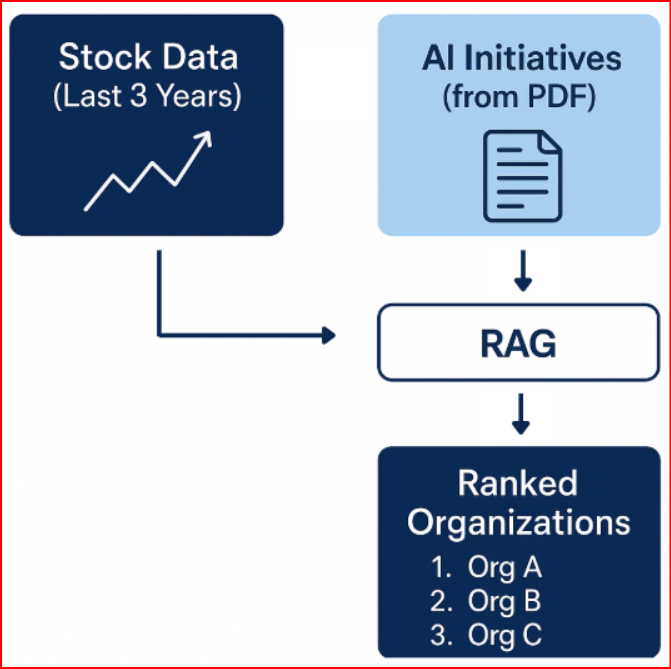

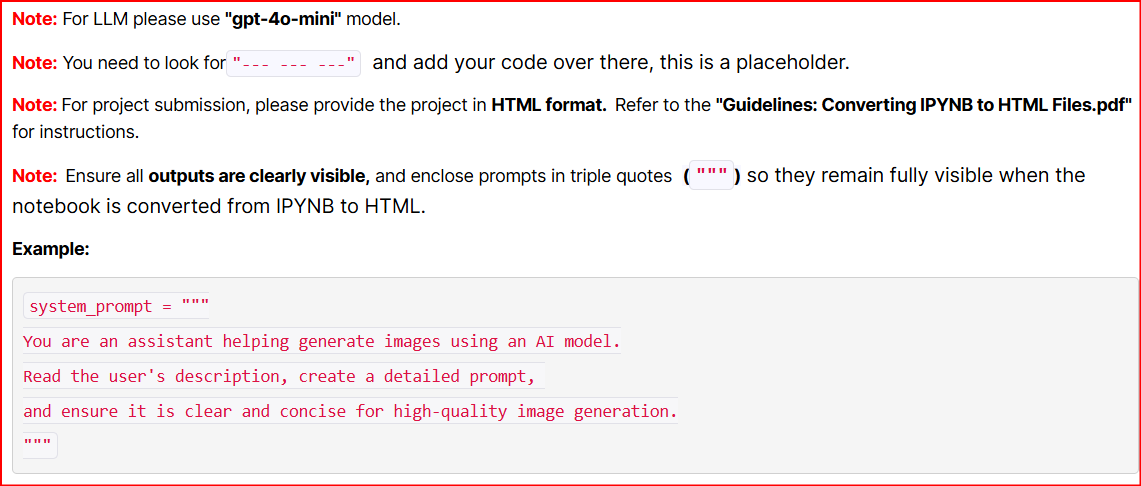

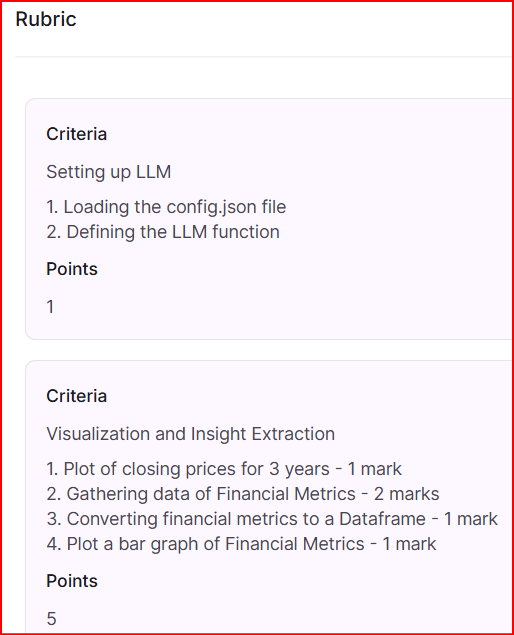

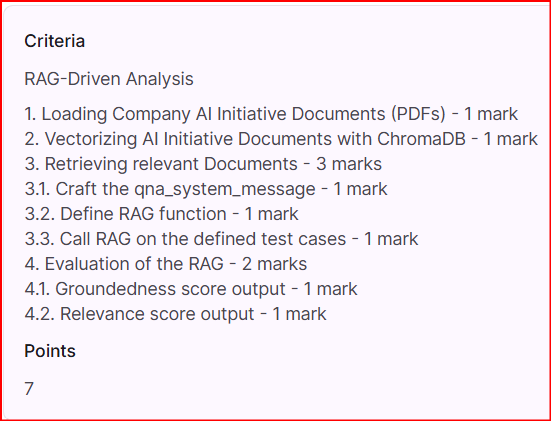

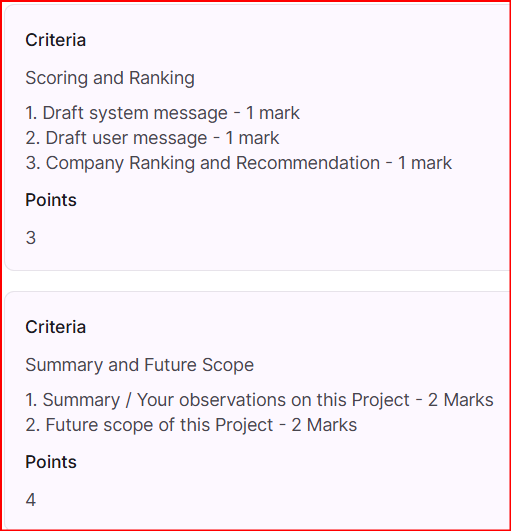

# **Environmental Set Up for Imports**

In [ ]:
!pip install langchain==0.3.25 \
                langchain-core==0.3.65 \
                langchain-openai==0.3.24 \
                chromadb==0.6.3 \
                langchain-community==0.3.20 \
                pypdf==5.4.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.5 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of langchain-text-splitters to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.1/438.1 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.1/611.1 kB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 82.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.0

In [6]:

p install langchain-openai

In [ ]:
import yfinance as yf              # Used for gathering stock prices
import matplotlib.pyplot as plt    # Used for Data Visualization / Plots / Graphs
import pandas as pd                # Helpful for working with tabular data like DataFrames
import os                          # Interacting with the operating system

from langchain.text_splitter import RecursiveCharacterTextSplitter      #  Helpful in splitting the PDF into smaller chunks

from langchain_community.document_loaders import PyPDFDirectoryLoader, PyPDFLoader     # Loading a PDF
from langchain_community.vectorstores import Chroma    # Vector DataBase

# **1. Select Organizations for Review**

In [7]:

companies = ["GOOGL", "MSFT", "IBM", "NVDA", "AMZN"]

# **2. LLM set up - 1 Marks**

The config.json file should contain API_KEY and API BASE URL provided by OpenAI.
You need to insert your actual API keys and endpoint URL obtained from your Olympus account. Refer to the OpenAI Access Token documentation for more information on how to generate and manage your API keys.
This code reads the config.json file and extracts the API details.
The API_KEY is a unique secret key that authorizes your requests to OpenAI's API.
The OPENAI_API_BASE is the API BASE URL where the model will process your requests.
What To Do?

Use the sample config.json file provided.

Add their OpenAI API Key and Base URL to the file.

The config.json should look like this:

{
      "API_KEY": "your_openai_api_key_here",
      "OPENAI_API_BASE": "https://your_openai_api_base/v1"
    }

In [8]:
50%%writefile config.json
{
      "API_KEY": "your_openai_api_key_here",
      "OPENAI_API_BASE": "https://your_openai_api_base/v1"
}

Overwriting config.json


In [9]:
#Loading the `config.json` file
import json
import os

# Load the JSON file and extract values
file_name = "config.json"
with open(file_name, 'r') as file:
    config = json.load(file)
    os.environ['OPENAI_API_KEY'] = config ["API_KEY"] # Loading the API Key
    os.environ["OPENAI_BASE_URL"] = config["OPENAI_API_BASE"] # Loading the API Base Url


from langchain_openai import ChatOpenAI
llm = ChatOpenAI(
    model="gpt-4o-mini",                      # "gpt-4o-mini" to be used as an LLM
    temperature=0,                # Set the temprature to 0
    max_tokens=5000,                 # Set the max_tokens = 5000, so that the long response will not be clipped off
    top_p=0.95,
    frequency_penalty=1.2,
    stop_sequences=['INST']
)

To create the `config.json` file, run the following cell. Then, click the folder icon on the left panel, navigate to the `/content` directory, find `config.json`, and edit it with your actual `API_KEY` and `OPENAI_API_BASE`.

# **3. Visualization and Insight Extraction - 5 Marks**

1. Loop through each company to retrieve stock data of the last three years using the YFinance library.

2. Plot the closing prices for each company.

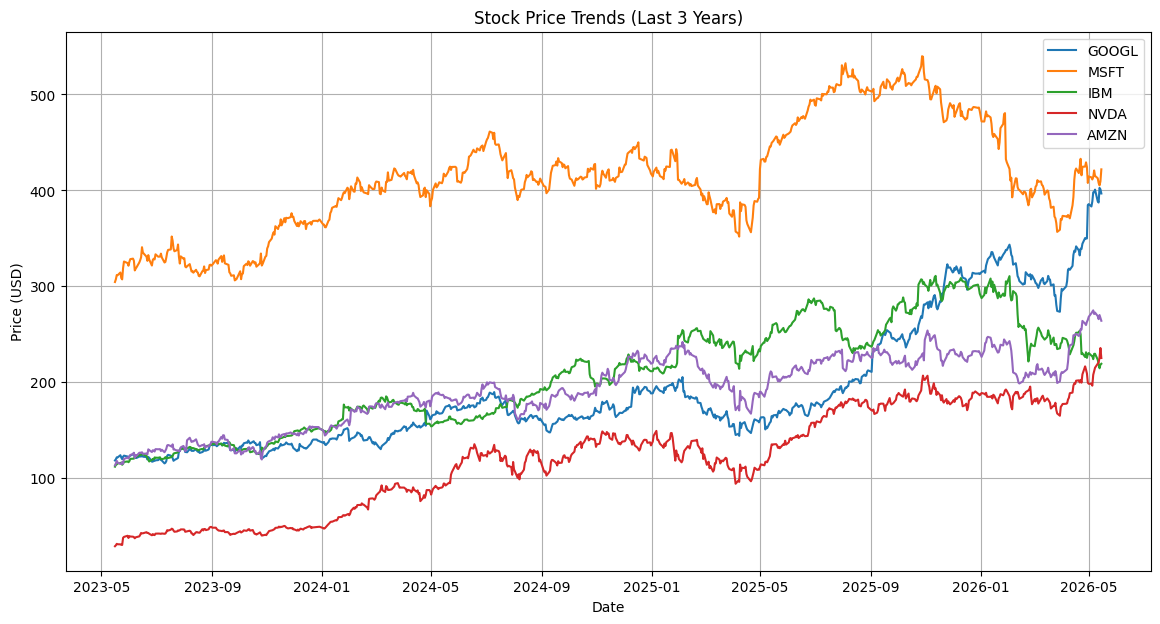

In [11]:
import matplotlib.pyplot as plt
import yfinance as yf

plt.figure(figsize=(14,7))

# Loop through each company and plot closing prices
for symbol in companies:
    ticker = yf.Ticker(symbol)
    data = ticker.history(period="3y")

    # Plot closing price
    plt.plot(data.index, data['Close'], label=symbol)

plt.title("Stock Price Trends (Last 3 Years)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.savefig("Stock_Price_Trends_3Y.png")
plt.show()

# **Financial Metrics**

Market Cap: Total market value of a company’s outstanding shares.
P/E Ratio: Shows how much investors are willing to pay per dollar of earnings.
Dividend Yield: Annual dividend income as a percentage of the stock price.
Beta: Measures a stock’s volatility relative to the overall market.
Total Revenue: The total income a company generates from its business operations.

**The Ask:**
1. Loop through all the companies to fetch data based on the specified financial metrics.

2. Create a DataFrame (DF) from the collected data.
Visualize and compare each financial metric across all companies.

For example, visualize and compare the market capitalization for each company.


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

companies = ["GOOGL", "MSFT", "IBM", "NVDA", "AMZN"]
metrics_list = {}

# Fetching the financial metrics
for symbol in companies:                          # Loop through all the companies
    ticker = yf.Ticker(symbol)
    info = ticker.info
    metrics_list[symbol] = {                              # Define the dictionary of all the Finanical Metrics
        "Market Cap": info.get("marketCap", 0),
        "P/E Ratio": info.get("trailingPE", 0),
        "Dividend Yield": info.get("didvidendYield", 0),
        "Beta": info.get("beta", 0),
        "Total Revenue": info.get("totalRevenue", 0)
    }



In [13]:
# Convert to DataFrame
df = pd.DataFrame(metrics_list).T

# Converting large numbers to billions for readability by divinding the whole column by 1e9
df["Market Cap"] = df["Market Cap"] / 1e9
df["Total Revenue"] = df["Total Revenue"] / 1e9
df["Dividend Yield"] = df["Dividend Yield"] * 100  # Convert to percentage

df   # Printing the df

,Market Cap,P/E Ratio,Dividend Yield,Beta,Total Revenue
GOOGL,4807.165739,30.311687,0.0,1.267,422.498009
MSFT,3134.205460,25.129244,0.0,1.093,318.272995
IBM,206.116848,19.424269,0.0,0.581,68.910998
NVDA,5457.368842,46.077713,0.0,2.244,215.938007
AMZN,2841.383010,31.633533,0.0,1.468,742.775980


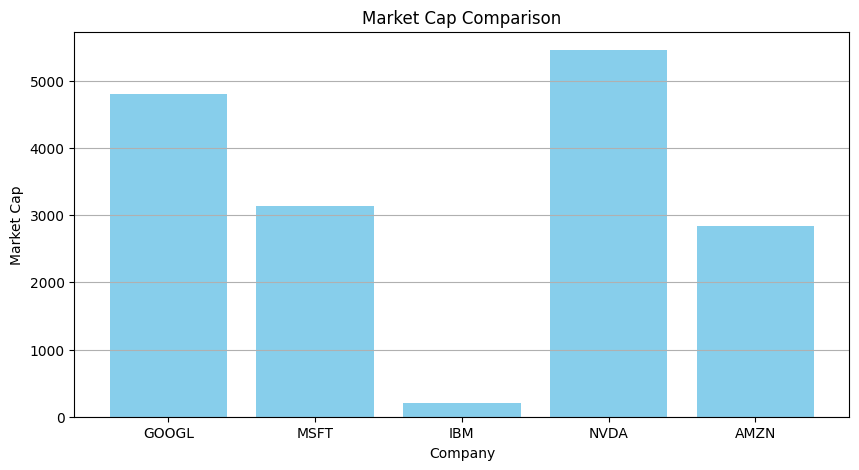

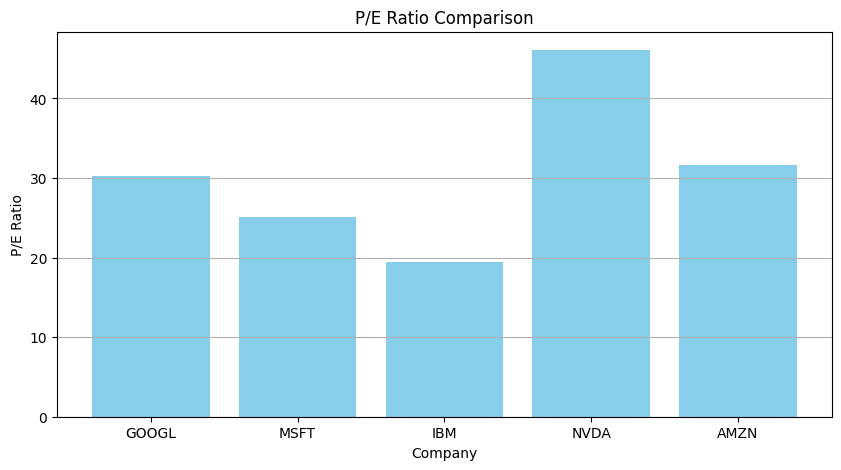

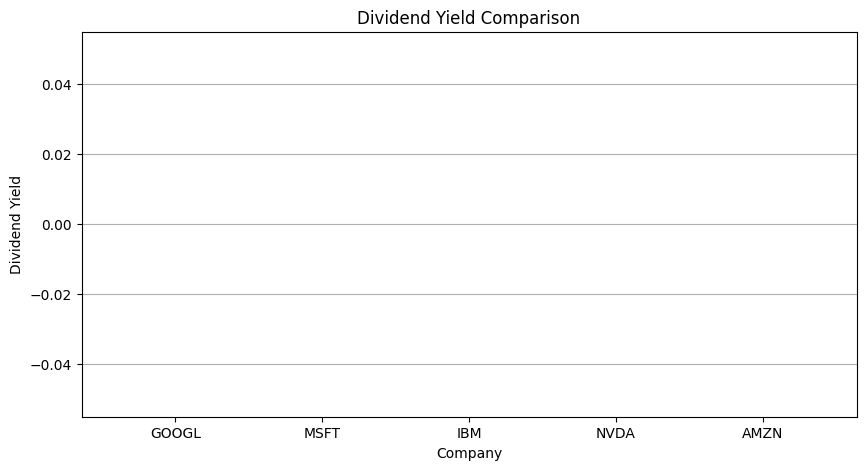

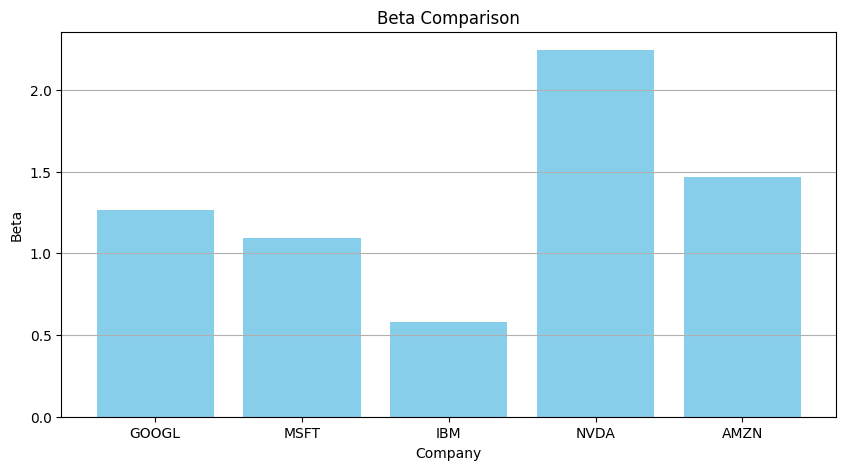

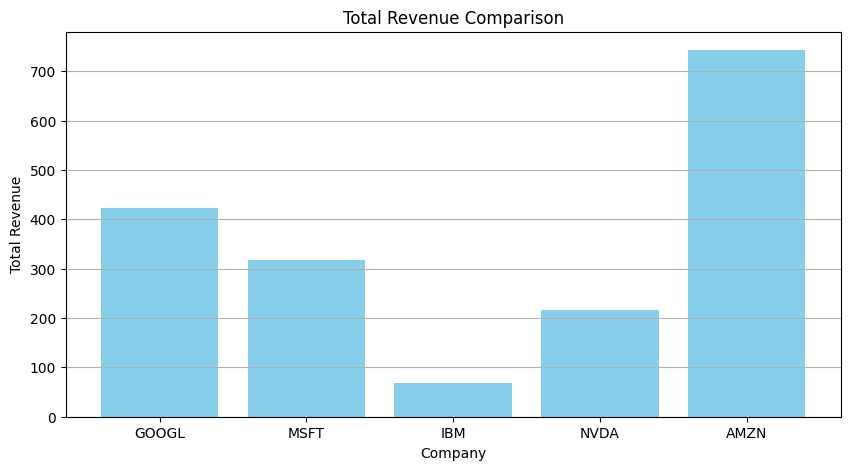

In [14]:
# Plot each metric as a separate bar graph
metrics_to_plot = ["Market Cap", "P/E Ratio", "Dividend Yield", "Beta", "Total Revenue"]

for metric in metrics_to_plot:
    plt.figure(figsize=(10,5))
    plt.bar(df.index, df[metric], color='skyblue')
    plt.title(f"{metric} Comparison")
    plt.ylabel(metric)
    plt.xlabel("Company")
    plt.grid(axis='y')
    plt.show()

# **4. RAG-Driven Analysis - 7 Marks**

# **The Assignment Ask:**

1. Extract all PDF files from the provided ZIP file.

2. Read the content from each PDF file.

3. Split the content into manageable chunks.

4. Store the chunks in a vector database using embedding functions.

5. Implement a query mechanism on the vector database to retrieve results based on user queries regarding AI initiatives.

6. Evaluate the LLM generated response using LLM-as-Judge.

# **1. Loading Company AI Initiative Documents (PDFs) - 1 mark**

In [17]:
import zipfile
import os

zip_file_name = "Companies-AI-Initiatives.zip"
extract_path = "/content/"

# Check if the zip file exists before attempting to open it
if not os.path.exists(zip_file_name):
    print(f"Error: The file '{zip_file_name}' was not found.")
    print("Please upload the ZIP file to your Colab environment by clicking the 'Files' icon on the left sidebar and then the 'Upload' button.")
    print("Alternatively, you can use the complete solution provided in cell 'c96_XqMA6l8N' which handles the upload and extraction automatically.")
else:
    try:
        with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
            zip_ref.extractall(extract_path)         # Storing all the unzipped contents in this location
        print(f"Successfully unzipped '{zip_file_name}' to '{extract_path}'")
    except zipfile.BadZipFile:
        print(f"Error: The file '{zip_file_name}' is not a valid zip file. Please ensure you have uploaded the correct file.")
    except Exception as e:
        print(f"An unexpected error occurred during unzipping: {e}")

Error: The file 'Companies-AI-Initiatives.zip' was not found.
Please upload the ZIP file to your Colab environment by clicking the 'Files' icon on the left sidebar and then the 'Upload' button.
Alternatively, you can use the complete solution provided in cell 'c96_XqMA6l8N' which handles the upload and extraction automatically.


In [21]:
!ls

config.json  sample_data  Stock_Price_Trends_3Y.png


In [24]:
c96_XqMA6l8N = "some value"
print(c96_XqMA6l8N)

some value


In [28]:
c96_XqMA6l8N

'some value'

In [27]:
# Path of all AI Initiative Documents
import os
ai_initiative_pdf_paths = [f"/content/Companies-AI-Initiatives/{file}" for file in os.listdir("/content/Companies-AI-Initiatives") if file.endswith('.pdf')]
ai_initiative_pdf_paths

FileNotFoundError: [Errno 2] No such file or directory: '/content/Companies-AI-Initiatives'

In [ ]:
from langchain_community.document_loaders import PyPDFDirectoryLoader
loader = PyPDFDirectoryLoader(path = "/content/companies-AI-Initiatives")          # Creating an PDF loader object

In [1]:
# Defining the text splitter
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    encoding_name='cl100k_base',
    chunk_size=1000,
    chunk_overlap=200
)

NameError: name 'RecursiveCharacterTextSplitter' is not defined

**# Splitting the chunks using the text splitter**


In [ ]:
ai_initiative_chunks = loader.load_and_split(text_splitter)

In [ ]:
# Total length of all the chunks
len(ai_initiative_chunks)

# **2. Vectorizing AI Initiative Documents with ChromaDB - 1 mark**

In [ ]:
# Defining the 'text-embedding-ada-002' as the embedding model
from langchain_openai import OpenAIEmbeddings
embedding_model = OpenAIEmbeddings(model="text-embedding-ada-002")


In [ ]:
# COMPLETE SOLUTION - RUN THIS ENTIRE CELL
from google.colab import files
import zipfile
import os
from langchain_community.document_loaders import PyPDFDirectoryLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import Chroma

print("STEP 1: Upload ZIP file")
print("=" * 60)
uploaded = files.upload()
zip_filename = list(uploaded.keys())[0]
print(f"✓ Uploaded: {zip_filename}\n")

print("STEP 2: Extract ZIP file")
print("=" * 60)
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    print("Files in ZIP:")
    for file in zip_ref.namelist():
        print(f"  - {file}")
    zip_ref.extractall("./")
print("✓ Extraction complete\n")

print("STEP 3: Find PDF files")
print("=" * 60)
pdf_files = []
pdf_directory = None
for root, dirs, files in os.walk("./"):
    for file in files:
        if file.endswith('.pdf'):
            full_path = os.path.join(root, file)
            pdf_files.append(full_path)
            if pdf_directory is None:
                pdf_directory = root
print(f"Found {len(pdf_files)} PDF files in: {pdf_directory}\n")

print("STEP 4: Load PDF documents")
print("=" * 60)
loader = PyPDFDirectoryLoader(path=pdf_directory)
documents = loader.load()
print(f"✓ Loaded {len(documents)} documents\n")

print("STEP 5: Split into chunks")
print("=" * 60)
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    encoding_name='cl100k_base',
    chunk_size=1000,
    chunk_overlap=200
)
ai_initiative_chunks = text_splitter.split_documents(documents)
print(f"✓ Created {len(ai_initiative_chunks)} chunks\n")

print("STEP 6: Create vectorstore")
print("=" * 60)
embedding_model = OpenAIEmbeddings(model="text-embedding-ada-002")
vectorstore = Chroma.from_documents(
    ai_initiative_chunks,
    embedding_model,
    collection_name="AI_Initiatives"
)
print("✓ Vectorstore created!\n")

print("STEP 7: Create retriever")
print("=" * 60)
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 10}
)
print("✓ Retriever ready!\n")

print("=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"PDF files: {len(pdf_files)}")
print(f"Documents: {len(documents)}")
print(f"Chunks: {len(ai_initiative_chunks)}")
print("✅ ALL DONE! Ready to query.")

In [ ]:
#  Creating a Vectorstore, storing all the above created chunks using an embedding model

vectorstore = Chroma.from_documents(
    ai_initiative_chunks,
    embedding_model,
    collection_name="AI_Initiatives"
)

# Ignore if it gives an error or warning

In [ ]:
# Creating an retriever object which can fetch ten similar results from the vectorstore
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 10}
)

# **3. Retrieving relevant Documents - 3 marks**

In [ ]:
user_message = "Give me the best project that `IBM` company is working upon"

In [ ]:
# Building the context for the query using the retrieved chunks
relevant_document_chunks = retriever.get_relevant_documents(user_message)
context_list = [d.page_content for d in relevant_document_chunks]
context_for_query = ". ".join(context_list)


In [ ]:
len(relevant_document_chunks)

In [ ]:
# Write a system message for an LLM to help craft a response from the provided context
qna_system_message = """

You are a helpful AI assistant specialized in analyzing company AI initiatives.
Your task is to provide accurate, detailed answers based solely on the context provided.
If the answer cannot be found in the context, clearly state that the information is not available.
Always cite specific details from the context in your response.

"""

In [ ]:
# Write an user message template which can be used to attach the context and the questions
qna_user_message_template = """
###Context
Here are some documents that are relevant to the question mentioned below.
{context}

###Question
{question}
"""



In [ ]:
# Format the prompt
formatted_prompt = f"""[INST]{qna_system_message}\n
                {'user'}: {qna_user_message_template.format(context=context_for_query, question=user_message)}
                [/INST]"""


In [ ]:
# Make the LLM call
resp = llm.invoke(formatted_prompt)
resp.content

In [ ]:
# Define RAG function
def RAG(user_message):
    """
    Args:
    user_message: Takes a user input for which the response should be retrieved from the vectorDB.
    Returns:
    relevant context as per user query.
    """
    relevant_document_chunks = retriever.get_relevant_documents(user_message)
    context_list = [d.page_content for d in relevant_document_chunks]
    context_for_query = ". ".join(context_list)



    # Combine qna_system_message and qna_user_message_template to create the prompt
    prompt = f"""[INST]{qna_system_message}\n
                {'user'}: {qna_user_message_template.format(context=context_for_query, question=user_message)}
                [/INST]"""

    # Quering the LLM
    try:
        response = llm.invoke(prompt)

    except Exception as e:
        response = f'Sorry, I encountered the following error: \n {e}'

    return response.content


In [ ]:
# Test Cases
print(RAG("How is the area in which GOOGL is working different from the area in which MSFT is working?"))


In [ ]:
print(RAG("What are the three projects on which MSFT is working upon?"))


In [ ]:
print(RAG("What is the timeline of each project in NVDA?"))

In [ ]:
print(RAG("What are the areas in which AMZN is investing when it comes to AI?"))

In [ ]:
print(RAG("What are the risks associated with projects within GOOG?"))

# **4. Evaluation of the RAG - 2 marks**

In [ ]:
# Writing a question for performing evaluations on the RAG
evaluation_test_question = "What are the three projects on which MSFT is working upon?"


In [ ]:
# Building the context for the evaluation test question using the retrieved chunks
relevant_document_chunks = retriever.get_relevant_documents(evaluation_test_question)
context_list = [d.page_content for d in relevant_document_chunks]
context_for_query = ". ".join(context_list)

In [ ]:
# Default RAG Answer
answer = RAG(evaluation_test_question)
print(answer)

In [ ]:
# Defining user messsage template for evaluation
evaluation_user_message_template = """
You are an expert evaluator for question-answering systems.
Evaluate the provided answer based on the following criteria:
1. Relevance: Does the answer address the question?
2. Accuracy: Is the answer factually correct based on the context?
3. Completeness: Does the answer cover all important aspects from the context?
4. Clarity: Is the answer clear and well-structured?

Provide a score from 1-10 for each criterion and an overall assessment.
"""



# **1. Groundedness**

In [ ]:
# Writing the system message and the evaluation metrics for checking the groundedness
groundedness_rater_system_message = """

You are an expert evaluator assessing the groundedness of answers generated by a question-answering system.

Your task is to evaluate whether the provided answer is fully grounded in the given context. An answer is considered grounded if:
1. All claims and statements in the answer can be directly traced back to information in the context
2. No information is fabricated, hallucinated, or inferred beyond what the context explicitly states
3. The answer does not include external knowledge not present in the context

Evaluation Criteria:
- **Fully Grounded (Score: 5)**: Every statement in the answer is directly supported by the context with no additions or hallucinations
- **Mostly Grounded (Score: 4)**: Most statements are supported by context, with minor interpretations that stay very close to the source
- **Partially Grounded (Score: 3)**: Some statements are supported, but the answer includes unsupported claims or inferences
- **Minimally Grounded (Score: 2)**: Few statements are supported; answer contains significant hallucinations or external information
- **Not Grounded (Score: 1)**: Answer is largely fabricated or contradicts the context

Provide:
1. A groundedness score (1-5)
2. Specific examples of grounded statements
3. Specific examples of any ungrounded or hallucinated content (if any)
4. Overall assessment and reasoning

"""

In [ ]:
# Combining groundedness_rater_system_message + llm_prompt + answer for evaluation
groundedness_prompt = f"""[INST]{groundedness_rater_system_message}\n
            {'user'}: {evaluation_user_message_template.format(context=context_for_query, question=evaluation_test_question, answer=answer)}
            [/INST]"""

In [ ]:
# Defining a new LLM object
groundness_checker = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    max_tokens=500,
    top_p=0.95,
    frequency_penalty=1.2,
    stop_sequences=['INST']
)

# Using the LLM-as-Judge for evaluating Groundedness
groundness_response = groundness_checker.invoke(groundedness_prompt)
print(groundness_response.content)


# **2. Relevance**

In [ ]:
# Writing the system message and the evaluation metrics for checking the relevance
relevance_rater_system_message = """

You are an expert evaluator assessing the relevance of answers generated by a question-answering system.

Your task is to evaluate whether the provided answer is relevant and directly addresses the user's question.

Evaluation Criteria:
- **Highly Relevant (Score: 5)**: The answer directly and completely addresses the question, providing all necessary information the user is seeking
- **Mostly Relevant (Score: 4)**: The answer addresses the main question but may miss some minor aspects or include slightly tangential information
- **Moderately Relevant (Score: 3)**: The answer is partially relevant but misses key aspects of the question or includes significant irrelevant information
- **Slightly Relevant (Score: 2)**: The answer touches on the topic but fails to address the core question or is mostly off-topic
- **Not Relevant (Score: 1)**: The answer does not address the question at all or is completely off-topic

Provide:
1. A relevance score (1-5)
2. Explanation of how well the answer addresses the specific question asked
3. Identification of any missing information that should have been included
4. Identification of any irrelevant information that was unnecessarily included
5. Overall assessment and recommendations for improvement

"""

In [ ]:
# Combining relevance_rater_system_message + llm_prompt + answer for evaluation
relevance_prompt = f"""[INST]{relevance_rater_system_message}\n
            {'user'}: {evaluation_user_message_template.format(context=context_for_query, question=evaluation_test_question, answer=answer)}
            [/INST]"""


In [ ]:
# Defining a new LLM object
relevance_checker = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    max_tokens=500,
    top_p=0.95,
    frequency_penalty=1.2,
    stop_sequences=['INST']
)

# Using the LLM-as-Judge for evaluating Relevance
relevance_response = relevance_checker.invoke(relevance_prompt)
print(relevance_response.content)

1. **Relevance Score**: 5

2. **Explanation**: The answer directly addresses the user's question by evaluating the provided answer based on the specified criteria of relevance, accuracy, completeness, and clarity.

3. **Missing Information**: There is no missing information as all four criteria were addressed in a structured manner.

4. **Irrelevant Information**: There is no irrelevant information included; the response stays focused on evaluating according to the given criteria.

5. **Overall Assessment and Recommendations for Improvement**: The evaluation is thorough and meets all aspects of what was asked by the user. To enhance clarity further, it could be beneficial to provide specific examples or explanations for each score given in relation to each criterion (e.g., why a certain score was assigned). However, this does not detract from its overall effectiveness in addressing the user's request comprehensively.

# **5. Scoring and Ranking - 3 Marks**

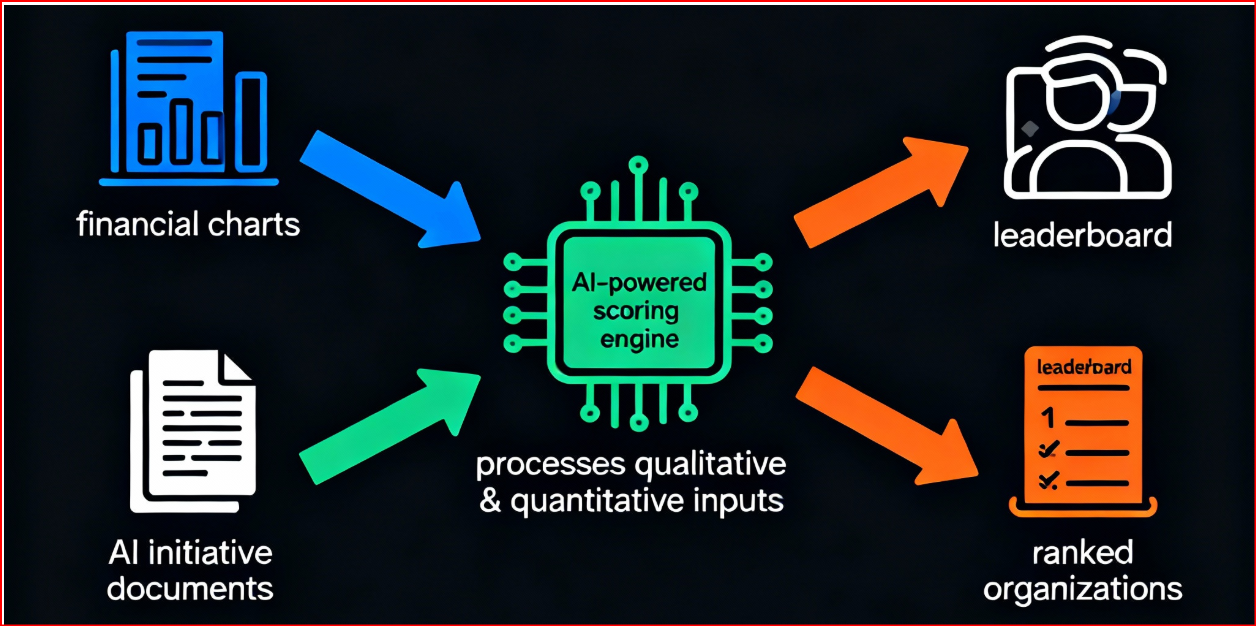

# **The Ask**

1. Write a system message and a user message that outlines the required data for the prompt.

2. Prompt the LLM to rank and recommend companies for investment based on the provided PDF and stock data to achieve better returns.

In [ ]:

# Fetching all the links of the documents
len(vectorstore.get()['documents'])

In [ ]:
# Write a system message for instructing the LLM for scoring and ranking the companies
system_message = """

You are an expert financial analyst and AI technology evaluator specializing in evaluating tech companies for investment purposes.

Your task is to analyze and rank companies based on two key dimensions:
1. **Financial Performance**: Evaluate companies using metrics like Market Cap, P/E Ratio, Dividend Yield, Beta, and Total Revenue
2. **AI Innovation and Strategy**: Assess the quality, scope, and potential impact of each company's AI initiatives

For each company, provide:
- A comprehensive score out of 100 (combining financial strength and AI innovation)
- Breakdown of scores: Financial Score (50 points max) and AI Innovation Score (50 points max)
- Key strengths and weaknesses
- Investment recommendation (Strong Buy, Buy, Hold, Sell, Strong Sell)
- Risk assessment

Finally, rank all companies from most to least attractive for investment, with clear justification for the rankings.
 """

In [ ]:
# Write a user message for instructing the LLM for scoring and ranking the companies
user_message = f"""

Please analyze and rank the following tech companies based on their financial performance and AI initiatives.

Use the financial data and AI initiative documents provided below to create a comprehensive evaluation and ranking.

For each company, provide:
1. Overall Score (out of 100)
2. Financial Score (out of 50) - based on market cap, P/E ratio, revenue, beta, dividend yield
3. AI Innovation Score (out of 50) - based on the quality, scope, and strategic importance of AI initiatives
4. Key Strengths (top 3)
5. Key Weaknesses or Risks (top 3)
6. Investment Recommendation

Then provide a final ranking of all companies from 1 (best) to 5 (worst) with detailed justification.



---
### 1. Financial Data
{df.to_string()}

---
### 2. AI Initiatives
{vectorstore.get()['documents']}
"""

In [ ]:
# Formatting the prompt
formatted_prompt = f"""[INST]{system_message}\n
                {'user'}: {user_message}
                [/INST]"""

In [ ]:
# Calling the LLM
recommendation = llm.invoke(formatted_prompt)
recommendation.content

In [ ]:
print(recommendation.content)